# Phase 2 — Étude exploratoire

Objectif : comprendre ce qui fait varier les réactions d'un post **avant** de modéliser,
et repérer les pièges du jeu de données.

## La cible : `interactions`

`interactions = likes + commentaires`

Un choix délibéré, contre le réflexe habituel du *taux d'engagement*
(interactions ÷ abonnés). Le projet vise les **petits comptes**, et à cette échelle le
taux devient instable : avec 48 abonnés, un seul like de plus déplace le taux de
2 points, contre 0,02 point pour un compte de 5 000. Diviser par un dénominateur
minuscule fabrique du bruit.

Le nombre d'abonnés reste dans le jeu de données comme **variable explicative à part
entière** (`followers`), et non comme dénominateur. C'est au modèle d'apprendre son
effet, pas à nous de l'imposer par une division.

## Ce qui est écarté, et ce qui est gardé

Deux situations à ne surtout pas confondre :

| Cas | Ce que renvoie l'API | Décision |
|---|---|---|
| Le compte masque ses likes | clé `like_count` absente | **écarté** — la cible est inconnue |
| Le post a vraiment fait zéro like | `like_count = 0` | **gardé** — un flop est une information |

567 posts sont dans le premier cas et sortent de l'entraînement. 24 posts sont dans le
second et y restent : savoir qu'un post n'a rien récolté est un signal légitime. Un post
à zéro like peut d'ailleurs avoir des commentaires, auquel cas ses `interactions` ne sont
pas nulles.

Mon compte personnel est aussi mis de côté : il sert de cas d'usage final, pas d'exemple
d'entraînement.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src.viz.style import (DIVERGENT, INK, THEMES, TYPES_POST, appliquer_style,
                           couleurs_theme, couleurs_type, etiqueter_barres, finir)

MODE = "light"
ink = appliquer_style(MODE)
C_THEME, C_TYPE, DIV = couleurs_theme(MODE), couleurs_type(MODE), DIVERGENT[MODE]

df = pd.read_csv(RACINE / "data/processed/dataset_clean.csv", parse_dates=["timestamp"])
u = df[df.utilisable_entrainement].copy()
print(f"{len(df)} posts collectes -> {len(u)} exploitables ({u.compte.nunique()} comptes)")
print(f"dont {(u.interactions == 0).sum()} posts a zero interaction (flops reels, conserves)")

4173 posts collectes -> 3587 exploitables (28 comptes)
dont 24 posts a zero interaction (flops reels, conserves)


---
## 1. Distribution de la cible

La forme de la distribution décide de tout le reste : quelle statistique citer, quelle
échelle utiliser, et comment mesurer l'erreur au moment de modéliser.

In [2]:
print(u.interactions.describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(1).to_string())
print(f"\nmoyenne {u.interactions.mean():.0f} contre mediane {u.interactions.median():.0f}"
      f"  ->  rapport x{u.interactions.mean() / u.interactions.median():.0f}")
print(f"posts au-dela de 1 000 interactions : {(u.interactions > 1000).mean() * 100:.1f} %")

count      3587.0
mean       1167.6
std       12485.3
min           0.0
5%           11.0
25%          37.0
50%          93.0
75%         214.0
95%        1422.6
99%       21561.7
max      528383.0

moyenne 1168 contre mediane 93  ->  rapport x13
posts au-dela de 1 000 interactions : 6.0 %


La moyenne (1 168) vaut **treize fois la médiane (93)**. La distribution est donc très
asymétrique : une poignée de posts viraux écrase tout le reste, jusqu'à 528 383
interactions pour le maximum.

**Conséquence n°1 : on raisonne en médiane dans tout ce notebook.** La moyenne ne
décrirait que les valeurs extrêmes.

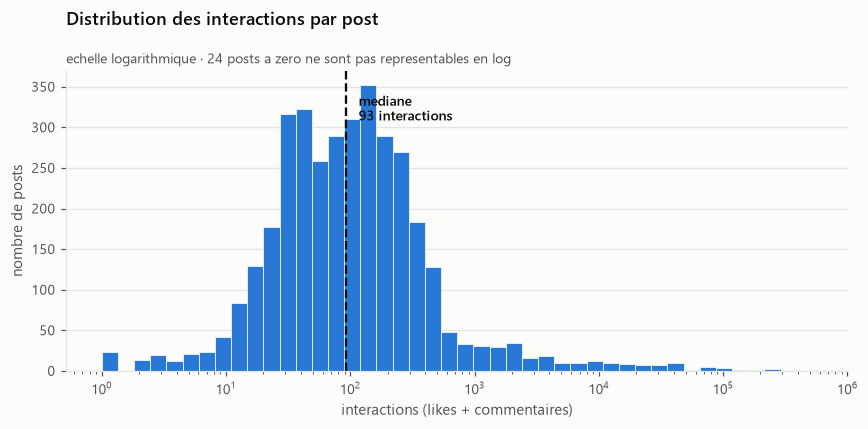

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
pos = u.interactions[u.interactions > 0]
bins = np.logspace(0, np.log10(pos.max()), 45)
ax.hist(pos, bins=bins, color=C_THEME["art"], edgecolor=ink["surface"], linewidth=0.5)
ax.set_xscale("log")

med = u.interactions.median()
ax.axvline(med, color=ink["primary"], linestyle="--", linewidth=1.5)
ax.annotate(f"mediane\n{med:.0f} interactions", (med, ax.get_ylim()[1] * 0.92),
            xytext=(8, 0), textcoords="offset points",
            color=ink["primary"], fontsize=9, va="top", fontweight="semibold")

finir(ax, "Distribution des interactions par post",
      f"echelle logarithmique · {(u.interactions == 0).sum()} posts a zero ne sont pas representables en log",
      "nombre de posts", "interactions (likes + commentaires)", MODE)
plt.tight_layout(); plt.show()

L'échelle logarithmique est indispensable : en échelle linéaire, la quasi-totalité des
posts s'écraserait dans la première barre. La forme obtenue est proche d'une log-normale.

**Conséquence n°2 : il faudra modéliser `log(1 + interactions)`.** Le `+1` permet de
conserver les 24 posts à zéro, dont le logarithme serait sinon indéfini. Sans cette
transformation, quelques posts viraux domineraient toute l'erreur d'apprentissage.

---
## 2. Une précaution de méthode : comparer chaque post à son propre compte

Avec `interactions` comme cible, un piège apparaît immédiatement : **un gros compte
produit plus d'interactions qu'un petit, quel que soit le contenu.** Comparer
directement les posts de comptes différents reviendrait donc à mesurer la taille des
comptes plutôt que la qualité des publications.

La parade consiste à rapporter chaque post à la médiane de **son propre compte** :

`interactions_relatives = interactions ÷ médiane des interactions du compte`

Une valeur de 1,20 signifie « ce post a fait 20 % de mieux que l'ordinaire de ce
compte ». Chaque compte est ainsi comparé à lui-même.

**Cette mesure a une limite stricte, qu'il faut avoir en tête :** elle vaut 1,0 pour tout
groupe défini au niveau du compte — thème, nombre d'abonnés — puisque chaque compte est
centré sur lui-même par construction. Elle ne sert donc qu'aux variables du **post**
(heure, format, texte). Pour les caractéristiques du **compte**, on reviendra aux valeurs
brutes, en assumant le biais.

Cette colonne n'est volontairement pas enregistrée dans le jeu de données : calculée à
partir de la cible, elle constituerait une fuite si on l'utilisait comme variable
d'entrée.

In [4]:
u["rel"] = u.interactions / u.groupby("compte").interactions.transform("median")

# Demonstration de la limite : la mesure relative est aveugle au niveau du compte
verif = u.groupby("theme").rel.median().round(3)
print("Mediane relative par theme (1,000 partout = la mesure ne voit pas le theme) :")
print(verif.to_string())

Mediane relative par theme (1,000 partout = la mesure ne voit pas le theme) :
theme
art             1.0
ecriture        1.0
melange         1.0
nature          1.0
photographie    1.0


---
## 3. Ce que le post contrôle

On regarde ici les leviers qui dépendent de la publication elle-même, avec la mesure
relative au compte.

In [5]:
stat = u.groupby("type_post").agg(
    posts=("id", "count"), mediane_brute=("interactions", "median"),
    moyenne_brute=("interactions", "mean"), relatif=("rel", "median")).reindex(TYPES_POST)
print(stat.round(2).to_string())
print(f"\nKruskal-Wallis sur la mesure relative : "
      f"p = {stats.kruskal(*[g.rel.values for _, g in u.groupby('type_post')]).pvalue:.2e}")

           posts  mediane_brute  moyenne_brute  relatif
type_post                                              
image        624          122.5         426.31     0.94
carrousel    916          110.0         463.19     1.05
video       2047           77.0        1708.72     0.98

Kruskal-Wallis sur la mesure relative : p = 4.13e-03


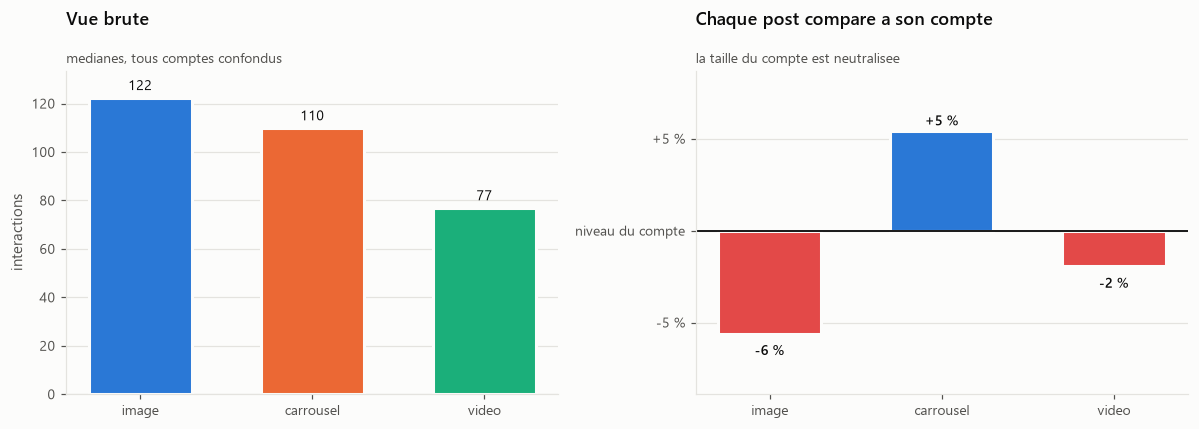

In [6]:
ecart = (stat.relatif - 1.0).values
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

b = axes[0].bar(range(3), stat.mediane_brute, width=0.6,
                color=[C_TYPE[t] for t in TYPES_POST],
                edgecolor=ink["surface"], linewidth=2)
etiqueter_barres(axes[0], b, stat.mediane_brute.values, "{:.0f}", MODE)
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(TYPES_POST)
finir(axes[0], "Vue brute", "medianes, tous comptes confondus",
      "interactions", None, MODE)

b2 = axes[1].bar(range(3), ecart, width=0.6,
                 color=[DIV["pos"] if e >= 0 else DIV["neg"] for e in ecart],
                 edgecolor=ink["surface"], linewidth=2)
axes[1].axhline(0, color=ink["primary"], linewidth=1.2)
for barre, e in zip(b2, ecart):
    axes[1].annotate(f"{e * 100:+.0f} %", (barre.get_x() + barre.get_width() / 2, e),
                     xytext=(0, 4 if e >= 0 else -14), textcoords="offset points",
                     ha="center", fontsize=9, color=ink["primary"], fontweight="semibold")
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(TYPES_POST)
axes[1].set_yticks([-0.05, 0, 0.05])
axes[1].set_yticklabels(["-5 %", "niveau du compte", "+5 %"])
axes[1].margins(y=0.3)
finir(axes[1], "Chaque post compare a son compte", "la taille du compte est neutralisee",
      None, None, MODE)
plt.tight_layout(); plt.show()

Les deux vues se contredisent, et c'est instructif.

En **brut**, l'image arrive en tête (122 interactions contre 77 pour la vidéo). En
**relatif**, l'ordre s'inverse : le carrousel passe devant (+5 %) et l'image tombe
dernière (−6 %). L'explication tient à la composition de l'échantillon — les images
proviennent surtout de comptes plus actifs en interactions — et illustre un cas classique
de **paradoxe de Simpson** : une tendance d'ensemble peut s'inverser une fois les groupes
correctement séparés.

La vue relative est la bonne pour répondre à « que devrais-je publier sur *mon* compte ».

Le contraste médiane / moyenne reste spectaculaire : **la vidéo a la médiane la plus
basse (77) mais de loin la plus forte moyenne (1 709)**. Elle se comporte comme un billet
de loterie : la plupart des reels font moins bien qu'une photo, mais ce sont eux qui
produisent tous les cartons.

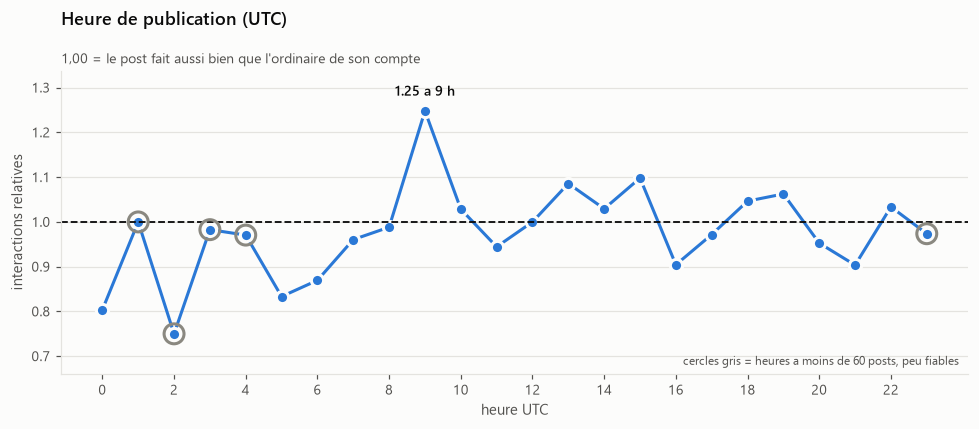

Kruskal-Wallis : p = 8.88e-04
amplitude : de 0.75 (2 h) a 1.25 (9 h)  ->  facteur 1.7


In [7]:
h = u.groupby("heure").agg(n=("id", "count"), rel=("rel", "median"))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(h.index, h.rel, color=C_THEME["art"], marker="o", markersize=8,
        markeredgecolor=ink["surface"], markeredgewidth=2, solid_capstyle="round")
ax.axhline(1.0, color=ink["primary"], linestyle="--", linewidth=1.2)

# Les heures creuses reposent sur peu de posts : on le montre plutot que de l'ecrire
maigre = h[h.n < 60]
ax.scatter(maigre.index, maigre.rel, s=170, facecolor="none",
           edgecolor=ink["muted"], linewidth=2, zorder=4)
ax.annotate("cercles gris = heures a moins de 60 posts, peu fiables",
            xy=(0.99, 0.03), xycoords="axes fraction", ha="right",
            fontsize=8, color=ink["secondary"])

pic = h.rel.idxmax()
ax.annotate(f"{h.rel.max():.2f} a {pic} h", (pic, h.rel.max()), xytext=(0, 10),
            textcoords="offset points", ha="center", fontsize=9,
            color=ink["primary"], fontweight="semibold")

ax.set_xticks(range(0, 24, 2))
ax.margins(y=0.18)
finir(ax, "Heure de publication (UTC)",
      "1,00 = le post fait aussi bien que l'ordinaire de son compte",
      "interactions relatives", "heure UTC", MODE)
plt.tight_layout(); plt.show()

print(f"Kruskal-Wallis : p = {stats.kruskal(*[g.rel.values for _, g in u.groupby('heure')]).pvalue:.2e}")
print(f"amplitude : de {h.rel.min():.2f} ({h.rel.idxmin()} h) a {h.rel.max():.2f} ({h.rel.idxmax()} h)"
      f"  ->  facteur {h.rel.max() / h.rel.min():.1f}")

L'heure a un effet réel et statistiquement net (p < 0,001), mais **d'ampleur modeste :
un facteur 1,7** entre le pire et le meilleur créneau, avec un pic marqué à 9 h UTC
(+25 %).

Une correction s'impose ici par rapport à une première version de cette analyse, qui
annonçait un facteur 4,5. Ce chiffre provenait d'un taux d'engagement calculé toutes
publications confondues : les créneaux horaires ne sont pas occupés par les mêmes
comptes, et l'écart mesurait donc en partie la taille des comptes qui publient à ces
heures-là. Une fois chaque post comparé au sien, l'effet retombe à 1,7. **C'est
exactement le genre de confusion que la mesure relative sert à éviter.**

Les heures creuses de la nuit, entourées sur le graphique, reposent sur très peu de
publications et ne doivent pas être sur-interprétées.

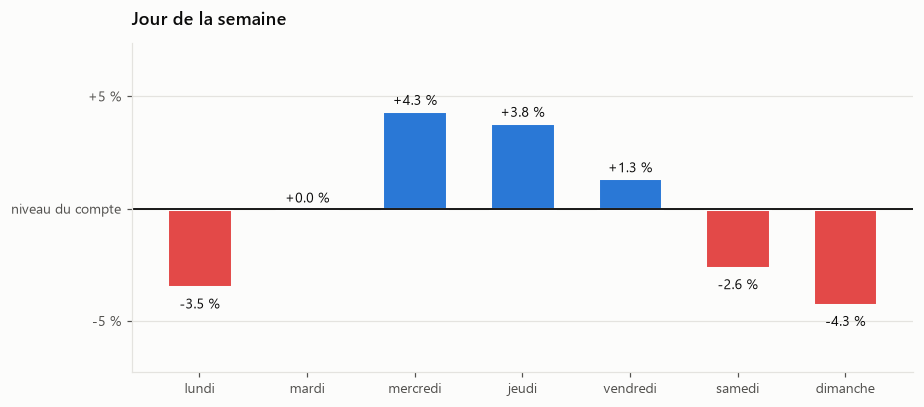

Kruskal-Wallis : p = 0.857  ->  AUCUN effet significatif


In [8]:
JOURS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
FR = ["lundi", "mardi", "mercredi", "jeudi", "vendredi", "samedi", "dimanche"]
j = u.groupby("nom_jour").rel.median().reindex(JOURS) - 1.0

fig, ax = plt.subplots(figsize=(8.5, 3.8))
b = ax.bar(range(7), j.values, width=0.6,
           color=[DIV["pos"] if v >= 0 else DIV["neg"] for v in j.values],
           edgecolor=ink["surface"], linewidth=2)
ax.axhline(0, color=ink["primary"], linewidth=1.2)
for barre, v in zip(b, j.values):
    ax.annotate(f"{v * 100:+.1f} %", (barre.get_x() + barre.get_width() / 2, v),
                xytext=(0, 4 if v >= 0 else -14), textcoords="offset points",
                ha="center", fontsize=9, color=ink["primary"])
ax.set_xticks(range(7)); ax.set_xticklabels(FR)
ax.set_yticks([-0.05, 0, 0.05]); ax.set_yticklabels(["-5 %", "niveau du compte", "+5 %"])
ax.margins(y=0.35)
finir(ax, "Jour de la semaine", None, None, None, MODE)
plt.tight_layout(); plt.show()

p = stats.kruskal(*[g.rel.values for _, g in u.groupby("jour_semaine")]).pvalue
print(f"Kruskal-Wallis : p = {p:.3f}  ->  {'effet significatif' if p < .05 else 'AUCUN effet significatif'}")

**Le jour de la semaine n'a aucun effet** (p = 0,86). Les sept valeurs tiennent dans une
bande de ±4 % autour du niveau habituel, ce qui est du bruit à ce volume.

Pour le modèle : l'heure mérite d'être une variable, le jour probablement pas.

---
## 4. Le texte de la légende

On teste ici les recettes que tout le monde répète : écrire long, empiler les hashtags,
mettre des emojis. Toujours sur la mesure relative au compte.

In [9]:
lignes = []
for col, label in [("longueur_legende", "longueur (caracteres)"),
                   ("nb_mots_legende", "nombre de mots"),
                   ("nb_hashtags", "nombre de hashtags"),
                   ("nb_emojis", "nombre d'emojis"),
                   ("nb_mentions", "nombre de mentions")]:
    rho, p = stats.spearmanr(u[col], u.rel)
    lignes.append({"variable": label, "rho": round(rho, 3), "p": p,
                   "significatif": "oui" if p < 0.05 else "non"})
print(pd.DataFrame(lignes).to_string(index=False))

             variable    rho        p significatif
longueur (caracteres)  0.080 0.000002          oui
       nombre de mots  0.076 0.000006          oui
   nombre de hashtags  0.047 0.004697          oui
      nombre d'emojis  0.047 0.005274          oui
   nombre de mentions -0.003 0.834417          non


Tous les rho sont compris entre −0,003 et +0,08 : **aucune de ces variables ne porte
d'information vraiment utile.** Certaines ressortent « significatives » uniquement parce
que 3 587 posts suffisent à détecter des liens infimes. Un rho de 0,08 correspond à
moins de 1 % de la variation expliquée.

Attention cependant : **Spearman ne détecte que les relations monotones.** Un effet en
cloche — quelques hashtags aident, beaucoup nuisent — produirait un rho proche de zéro
tout en étant bien réel. La cellule suivante teste donc par tranches.

In [10]:
NOMS = ["0", "1-5", "6-10", "11-20", "21+"]
u["tranche_ht"] = pd.cut(u.nb_hashtags, [-1, 0, 5, 10, 20, 1000], labels=NOMS)

bilan = u.groupby("tranche_ht", observed=True).agg(
    posts=("id", "count"), relatif=("rel", "median")).reindex(NOMS)
print(bilan.round(3).to_string())
print(f"\nKruskal-Wallis : p = "
      f"{stats.kruskal(*[g.rel.values for _, g in u.groupby('tranche_ht', observed=True)]).pvalue:.2e}")

            posts  relatif
tranche_ht                
0             946    0.915
1-5          1690    1.091
6-10          391    0.952
11-20         380    0.969
21+           180    0.957

Kruskal-Wallis : p = 5.12e-11


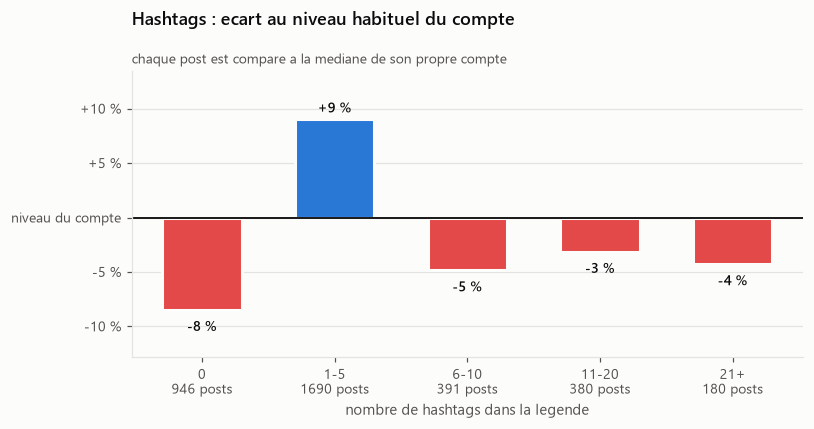

In [11]:
ecart = (bilan.relatif - 1.0).values

# Barres d'ecart ancrees au niveau du compte : un axe tronque sous des barres
# partant de zero exagererait un effet de l'ordre de 10 %.
fig, ax = plt.subplots(figsize=(7.5, 4))
b = ax.bar(range(len(NOMS)), ecart, width=0.6,
           color=[DIV["pos"] if e >= 0 else DIV["neg"] for e in ecart],
           edgecolor=ink["surface"], linewidth=2)
ax.axhline(0, color=ink["primary"], linewidth=1.2)
for barre, e in zip(b, ecart):
    ax.annotate(f"{e * 100:+.0f} %", (barre.get_x() + barre.get_width() / 2, e),
                xytext=(0, 4 if e >= 0 else -14), textcoords="offset points",
                ha="center", fontsize=9, color=ink["primary"], fontweight="semibold")
ax.set_xticks(range(len(NOMS)))
ax.set_xticklabels([f"{t}\n{int(n)} posts" for t, n in zip(NOMS, bilan.posts)])
ax.set_yticks([-0.10, -0.05, 0, 0.05, 0.10])
ax.set_yticklabels(["-10 %", "-5 %", "niveau du compte", "+5 %", "+10 %"])
ax.margins(y=0.25)
finir(ax, "Hashtags : ecart au niveau habituel du compte",
      "chaque post est compare a la mediane de son propre compte",
      None, "nombre de hashtags dans la legende", MODE)
plt.tight_layout(); plt.show()

Le découpage par tranches révèle ce que la corrélation masquait, et l'effet est
significatif (p < 10⁻¹⁰) : les posts portant **1 à 5 hashtags font 9 % de mieux** que
l'ordinaire de leur compte, tandis que ceux sans hashtag (−8 %) ou avec 6 et plus
(−3 à −5 %) font moins bien.

Deux précautions. D'abord l'ordre de grandeur : ±10 %, contre un facteur 1,7 pour
l'heure. Ensuite le sens : **rien n'indique qu'ajouter des hashtags cause un meilleur
résultat.** Un post soigné a des chances de recevoir à la fois une légende travaillée
avec quelques hashtags pertinents et un meilleur accueil, sans que l'un produise
l'autre.

La formulation honnête est donc : *empiler les hashtags n'apporte rien au-delà de cinq*,
et non *les hashtags ne servent à rien*.

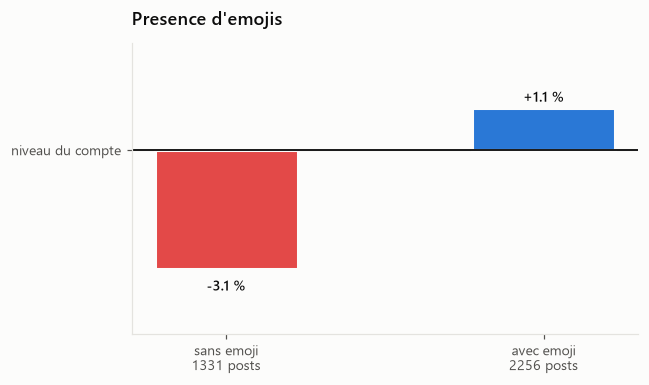

Mann-Whitney U : p = 0.003


In [12]:
groupes = [("sans emoji", u[~u.a_emoji]), ("avec emoji", u[u.a_emoji])]
ecart = [g.rel.median() - 1 for _, g in groupes]

fig, ax = plt.subplots(figsize=(6, 3.6))
b = ax.bar(range(2), ecart, width=0.45,
           color=[DIV["pos"] if e >= 0 else DIV["neg"] for e in ecart],
           edgecolor=ink["surface"], linewidth=2)
ax.axhline(0, color=ink["primary"], linewidth=1.2)
for barre, e in zip(b, ecart):
    ax.annotate(f"{e * 100:+.1f} %", (barre.get_x() + barre.get_width() / 2, e),
                xytext=(0, 4 if e >= 0 else -14), textcoords="offset points",
                ha="center", fontsize=9, color=ink["primary"], fontweight="semibold")
ax.set_xticks(range(2))
ax.set_xticklabels([f"{lab}\n{len(g)} posts" for lab, g in groupes])
ax.set_yticks([-0.05, 0, 0.05]); ax.set_yticklabels(["-5 %", "niveau du compte", "+5 %"])
ax.margins(y=0.4)
finir(ax, "Presence d'emojis", None, None, None, MODE)
plt.tight_layout(); plt.show()

p = stats.mannwhitneyu(u[u.a_emoji].rel, u[~u.a_emoji].rel).pvalue
print(f"Mann-Whitney U : p = {p:.3f}")

L'écart est **statistiquement significatif** (p = 0,003) mais **pratiquement négligeable** :
+1 % avec emoji contre −3 % sans. C'est la différence classique entre significativité
statistique et importance réelle — avec 3 587 posts, un écart de quelques pourcents
devient détectable sans pour autant mériter une recommandation.

---
## 5. Ce que le compte apporte

Ces caractéristiques appartiennent au compte, pas au post. La mesure relative y est
aveugle par construction, on revient donc aux valeurs brutes — avec la confusion que
cela implique.

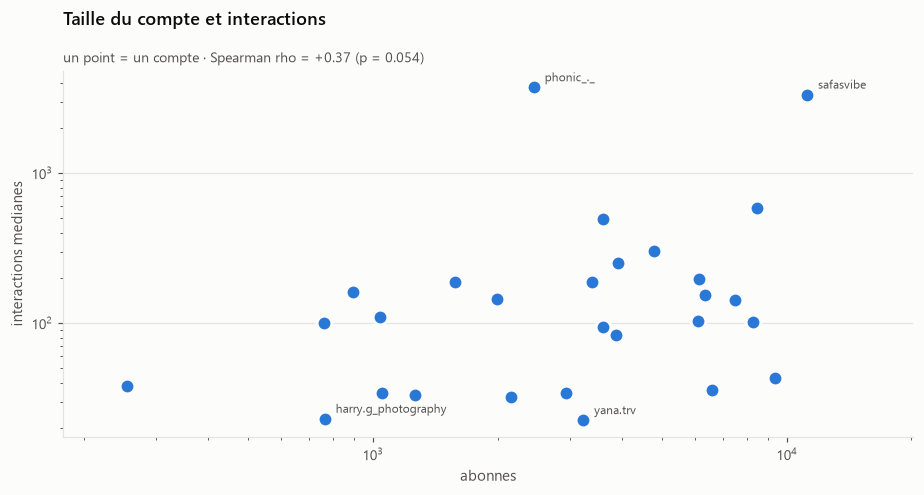

au niveau des comptes : rho = +0.368 (p = 0.0541, n = 28)
au niveau des posts   : rho = +0.175 (p = 3.8e-26, n = 3587)


In [13]:
parc = u.groupby("compte").agg(
    posts=("id", "count"), followers=("followers", "first"),
    med=("interactions", "median"), theme=("theme", "first")).sort_values("followers")

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.scatter(parc.followers, parc.med, s=95, color=C_THEME["art"],
           edgecolor=ink["surface"], linewidth=2, zorder=3)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(parc.followers.min() * 0.7, parc.followers.max() * 1.8)

for c in parc.nlargest(2, "med").index.tolist() + parc.nsmallest(2, "med").index.tolist():
    r = parc.loc[c]
    ax.annotate(c, (r.followers, r.med), xytext=(7, 4), textcoords="offset points",
                fontsize=8, color=ink["secondary"])

rho, p = stats.spearmanr(parc.followers, parc.med)
finir(ax, "Taille du compte et interactions",
      f"un point = un compte · Spearman rho = {rho:+.2f} (p = {p:.3f})",
      "interactions medianes", "abonnes", MODE)
plt.tight_layout(); plt.show()

rho_post, p_post = stats.spearmanr(u.followers, u.interactions)
print(f"au niveau des comptes : rho = {rho:+.3f} (p = {p:.4f}, n = {len(parc)})")
print(f"au niveau des posts   : rho = {rho_post:+.3f} (p = {p_post:.1e}, n = {len(u)})")

La relation est **positive**, comme attendu : un compte plus suivi récolte plus
d'interactions. Mais elle est **bien plus faible qu'on ne l'imaginerait** (rho = +0,37 au
niveau des comptes, à peine hors du seuil de significativité avec seulement 28 comptes).

Ce lien lâche a une bonne raison d'être : la part de l'audience qui réagit diminue quand
le compte grandit, ce qui compense en partie l'effet de taille. Un petit compte très
engageant peut donc rivaliser avec un compte bien plus gros.

C'est une excellente nouvelle pour l'objectif du projet : **le nombre d'abonnés ne
détermine pas à lui seul le résultat**, il reste de la place pour que le contenu compte.
En revanche, `followers` devra impérativement figurer parmi les variables du modèle,
faute de quoi celui-ci attribuerait au contenu ce qui vient de l'audience.

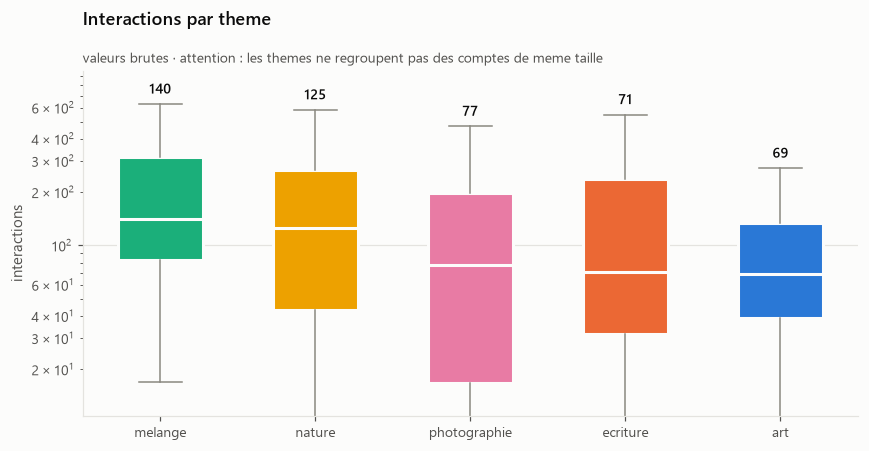

              posts  mediane  followers_median
theme                                         
art             856     69.0            2152.0
ecriture        608     71.0            6357.0
melange         432    140.0            3877.0
nature          899    125.0            1999.0
photographie    792     77.0            3226.0


In [14]:
ordre = u.groupby("theme").interactions.median().sort_values(ascending=False).index.tolist()
donnees = [u.loc[u.theme == t, "interactions"].values for t in ordre]

fig, ax = plt.subplots(figsize=(8, 4.2))
bp = ax.boxplot(donnees, patch_artist=True, showfliers=False, widths=0.55,
                medianprops=dict(color=ink["surface"], linewidth=2),
                whiskerprops=dict(color=ink["muted"]), capprops=dict(color=ink["muted"]))
for boite, t in zip(bp["boxes"], ordre):
    boite.set(facecolor=C_THEME[t], edgecolor=ink["surface"], linewidth=2)
ax.set_yscale("log")
ax.set_xticks(range(1, len(ordre) + 1)); ax.set_xticklabels(ordre)

for i, t in enumerate(ordre, start=1):
    m = u.loc[u.theme == t, "interactions"].median()
    haut = bp["caps"][2 * i - 1].get_ydata()[0]
    ax.annotate(f"{m:.0f}", (i, haut), xytext=(0, 7), textcoords="offset points",
                ha="center", fontsize=9, color=ink["primary"], fontweight="semibold")
ax.margins(y=0.12)
finir(ax, "Interactions par theme",
      "valeurs brutes · attention : les themes ne regroupent pas des comptes de meme taille",
      "interactions", None, MODE)
plt.tight_layout(); plt.show()

print(u.groupby("theme").agg(posts=("id", "count"), mediane=("interactions", "median"),
                             followers_median=("followers", "median")).round(0).to_string())

Mélange (140) et nature (125) devancent art (69), écriture (71) et photographie (77).

**Ce classement est à prendre avec des pincettes.** Les thèmes ne regroupent pas des
comptes de taille comparable : l'écriture rassemble les comptes les plus suivis (médiane
6 357 abonnés) tout en affichant des interactions basses, alors que nature (1 999
abonnés) fait mieux avec moins d'audience. Thème et taille de compte sont ici mélangés,
et seul un modèle tenant compte des deux pourra les démêler.

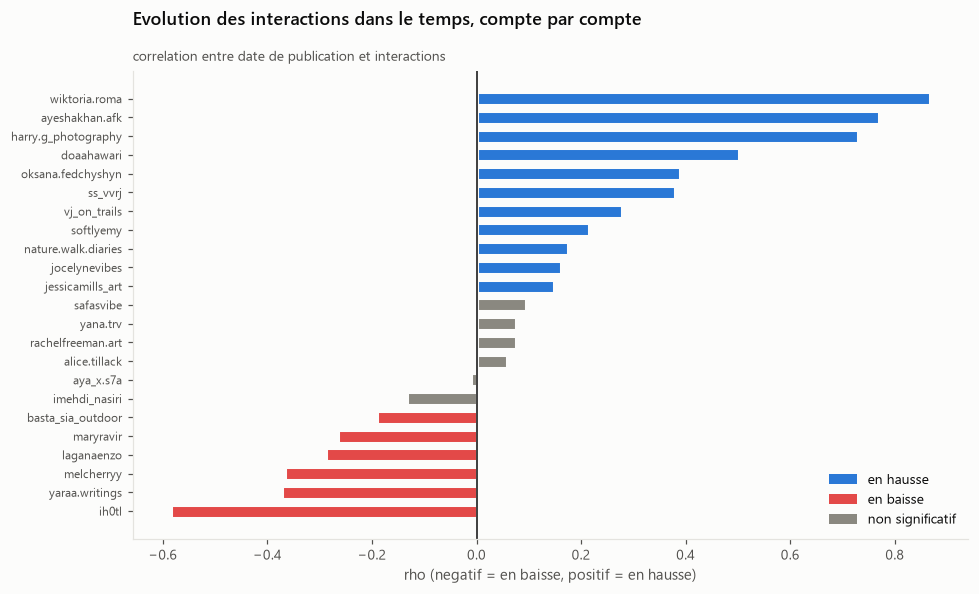

en hausse : 11   en baisse : 6   non significatif : 6


In [15]:
res = []
for c, g in u.groupby("compte"):
    if len(g) < 50:
        continue
    rho, p = stats.spearmanr(g.timestamp.astype("int64"), g.interactions)
    res.append({"compte": c, "posts": len(g), "rho": rho, "p": p})
tend = pd.DataFrame(res).sort_values("rho")

couleurs = [DIV["neg"] if (r.rho < 0 and r.p < .05)
            else DIV["pos"] if (r.rho > 0 and r.p < .05)
            else ink["muted"] for r in tend.itertuples()]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(range(len(tend)), tend.rho, color=couleurs,
        edgecolor=ink["surface"], linewidth=2, height=0.7)
ax.axvline(0, color=ink["primary"], linewidth=1)
ax.set_yticks(range(len(tend))); ax.set_yticklabels(tend.compte, fontsize=8)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=DIV["pos"], label="en hausse"),
                   Patch(facecolor=DIV["neg"], label="en baisse"),
                   Patch(facecolor=ink["muted"], label="non significatif")],
          loc="lower right")
finir(ax, "Evolution des interactions dans le temps, compte par compte",
      "correlation entre date de publication et interactions",
      None, "rho (negatif = en baisse, positif = en hausse)", MODE)
plt.tight_layout(); plt.show()

print(f"en hausse : {((tend.rho > 0) & (tend.p < .05)).sum()}   "
      f"en baisse : {((tend.rho < 0) & (tend.p < .05)).sum()}   "
      f"non significatif : {(tend.p >= .05).sum()}")

Il n'y a pas de tendance générale du marché : chaque compte suit sa propre trajectoire,
avec autant de comptes en progression qu'en recul.

Un avantage de la nouvelle cible mérite d'être noté : mesurée en interactions brutes,
cette tendance est **honnête**. Avec l'ancien taux d'engagement, elle était faussée — le
dénominateur était le nombre d'abonnés *actuel*, si bien que les vieux posts d'un compte
ayant beaucoup grandi paraissaient artificiellement faibles, créant une fausse
progression. Ici, une hausse traduit une vraie hausse des réactions, même si elle reflète
souvent la croissance de l'audience plutôt qu'une amélioration du contenu.

---
## 6. Bilan chiffré

In [16]:
print("=== De la collecte au jeu exploitable ===")
print(f"  posts collectes                  : {len(df):>5}")
print(f"  - likes masques (cible inconnue) : {-df.likes_masques.sum():>5}")
print(f"  - compte perso (cas d'usage)     : {-(df.groupe_split == 'cas_usage').sum():>5}")
print(f"  = exploitables                   : {df.utilisable_entrainement.sum():>5}")
print(f"  dont zero interaction (conserves): {(u.interactions == 0).sum():>5}")

print("\n=== Decoupage train / validation ===")
bilan = u.groupby("groupe_split").agg(comptes=("compte", "nunique"), posts=("id", "count"))
bilan["part_%"] = (bilan.posts / bilan.posts.sum() * 100).round(1)
print(bilan.to_string())

print("\n=== Repartition par theme ===")
print(pd.crosstab(u.theme, u.groupe_split, margins=True, margins_name="total").to_string())

=== De la collecte au jeu exploitable ===
  posts collectes                  :  4173
  - likes masques (cible inconnue) :  -567
  - compte perso (cas d'usage)     :   -19
  = exploitables                   :  3587
  dont zero interaction (conserves):    24

=== Decoupage train / validation ===
              comptes  posts  part_%
groupe_split                        
train              21   2651    73.9
validation          7    936    26.1

=== Repartition par theme ===
groupe_split  train  validation  total
theme                                 
art             656         200    856
ecriture        525          83    608
melange         280         152    432
nature          529         370    899
photographie    661         131    792
total          2651         936   3587


### Ce que retient la phase 2

**Sur les données**

| Élément | Valeur |
|---|---|
| Posts collectés | 4 173 |
| Posts exploitables | 3 587 (86 %) |
| Comptes | 28 (+ 1 cas d'usage) |
| Train | 2 651 posts / 21 comptes |
| Validation | 936 posts / 7 comptes (26 %) |
| Cible médiane | 93 interactions |

Le découpage est fait **par compte et non par post** : deux posts d'un même compte
partagent son audience et son style, donc les répartir entre train et validation ferait
fuiter de l'information et gonflerait artificiellement le score. Contrepartie assumée :
les thèmes sont inégalement répartis entre les deux groupes. Avec 28 comptes, on ne peut
pas équilibrer à la fois les comptes et les thèmes.

**Sur le contenu**

| Effet | Ampleur | Niveau |
|---|---|---|
| Taille du compte | rho = +0,37 | compte |
| Thème du compte | rapport 2 entre extrêmes, confondu avec la taille | compte |
| Heure de publication | facteur 1,7, pic à 9 h UTC | post |
| Format du post | carrousel +5 %, image −6 % | post |
| Nombre de hashtags | 1 à 5 valent +9 %, au-delà l'effet s'annule | post |
| Présence d'emojis | +1 %, négligeable malgré p = 0,003 | post |
| Longueur de légende | rho = +0,08, sous 1 % de variation | post |
| Jour de la semaine | aucun (p = 0,86) | post |

**Quatre décisions pour la phase 3**

1. **Modéliser `log(1 + interactions)`.** La distribution est log-normale et le `+1`
   conserve les 24 posts à zéro.
2. **Inclure `followers` comme variable explicative**, jamais comme dénominateur. Le lien
   avec la cible est réel mais lâche, ce qui laisse de la place au contenu.
3. **Encoder les hashtags par tranches, pas en compte brut.** L'effet est en cloche : une
   variable linéaire le manquerait entièrement, comme l'a fait Spearman ici.
4. **Ne pas compter sur les métadonnées textuelles simples.** Comptages d'emojis et de
   caractères n'expliquent presque rien : la valeur du NLP devra venir du *sens* de la
   légende.

**Deux mises en garde**

*Sur la causalité.* Tout ce qui précède décrit des **associations**. Rien ici ne permet
d'affirmer que publier à 9 h ou ajouter trois hashtags *provoque* plus de réactions. Les
comptes qui publient au bon moment sont vraisemblablement aussi ceux qui soignent le
reste.

*Sur la portée.* L'échantillon couvre 255 à 11 209 abonnés, dans des univers créatifs.
Le modèle ne saura rien dire d'un compte de 100 000 abonnés ni d'un autre secteur. Mon
propre compte, avec 48 abonnés, se situe même **sous la plage d'entraînement** : les
prédictions le concernant resteront fragiles tant que le jeu ne comptera pas davantage de
très petits comptes.

Le vrai enseignement de cette phase reste que **l'essentiel de la variation demeure
inexpliqué** par ces variables simples. C'est précisément ce que l'image et le contenu
sémantique devront capter en phase 3.